# Model LDA w ramach ryzyka operacyjnego

# Antoni Kois

### Pytania teoretyczne:

#### Wyjaśnić jakie ryzyko mierzy ryzyko operacyjne.

Ad:
Ryzyko operacyjne to ryzyko tego, że firma straci pieniądze przez błędy wewnątrz samej firmy albo przez zdarzenia z zewnątrz, na które nie ma wpływu. Chodzi tu przede wszystkim o awarie systemów informatycznych, błędy ludzkie czy oszustwa, zarówno te wewnętrzne (czyli dokonywane przez samych pracowników, np. sprzeniewierzenie własności, fałszowanie sprawozdań), jak i zewnętrzne (hakerzy, napady, kradzież informacji). Obejmuje to też sytuacje losowe, jak zniszczenie fizycznych aktywów na skutek siły wyższej (np. powódź, tornado). Co bardzo ważne, z definicji wyklucza się tu ryzyko strategiczne (czyli to, że zarząd podejmie złą decyzję biznesową) oraz ryzyko utraty reputacji. Mówiąc najprościej, mierzę tu po prostu ryzyko potknięć organizacyjnych.

#### Na podstawie treści z wykładu (oraz ew. innych wiarygodnych źródeł) wyjaśnić, jak obecnie wyznacza się ryzyko operacyjne w bankach. Dlaczego metoda rozkładu strat (LDA) nie jest uważana za optymalną? 

Ad:
Obecnie banki wyznaczają ryzyko operacyjne (a dokładniej liczą potrzebny kapitał regulacyjny na jego zabezpieczenie), posługując się metodami zaleconymi przez Komitet w Bazylei. Mają do wyboru kilka podejść o różnym stopniu skomplikowania.

- Najprostsza to metoda wskaźnika bazowego (BIA), która polega po prostu na wzięciu 15 procent od średniej z wyników banku wypracowanych przez ostatnie trzy lata.
- Kolejna to metoda standardowa (TSA), w której dzieli się działalność na 8 linii biznesowych i przypisuje im sztywne współczynniki ryzyka od 12 do 18 procent.
- Największe banki mogą jednak posługiwać się metodami zaawansowanymi (AMA), w ramach których najchętniej wybierana jest właśnie metoda rozkładu strat (LDA), służąca do symulacyjnego obliczania miary OpVaR.

Mimo że metoda rozkładu strat (LDA) jest zaawansowana matematycznie, nie uchodzi za optymalną z powodu kilku kluczowych wad:
- Największym problemem jest dostęp do odpowiednich danych. Banki zazwyczaj nie mają wystarczająco dużej bazy własnych strat historycznych, często borykają się z opóźnieniami w raportowaniu czy wysokimi progami odcięcia (np. raportują tylko duże wpadki, gubiąc masę małych strat). Żeby jakoś temu zaradzić, ściągają dane z zewnętrznych instytucji, co z kolei tworzy potężny problem z tym, jak takie cudze straty przeskalować do własnych realiów i wielkości własnego banku.
- Kolejnym minusem jest to, że model ten w całości opiera się na historii, zakładając w ciemno, że przeszłość powtórzy się w przyszłości.
- Dodatkowo, matematyka za tym stojąca jest trudna przy próbie połączenia i wyznaczenia powiązań (korelacji) pomiędzy różnymi liniami biznesowymi, czy uwzględniania strat ekstremalnych, których w historycznych ogonach rozkładu po prostu brakuje.
To wszystko sprawia, że wymóg kapitałowy może zostać wyliczony w sposób niepoprawny do faktycznego ryzyka w banku.

### Zadanie praktyczne:
Do wykonania poniższego zadania należy wykorzystać plik z katalogu dane, który zawiera dane dotyczące wysokości strat brutto dla wybranego okresu oraz kategorii ryzyka. Stosując AMA (a dokładniej model LDA), wykorzystując dwie dowolne linie biznesowe (w pliku jest ich siedem - do analizy należy wybrać dowolne dwie) należy wyznaczyć roczny 99,9% OpVaR oraz OpES dla danego banku.

W tym celu:
- Przeprowadzić krótką EDA pokazującą częstotliwość oraz dotkliwość strat operacyjnych w ramach wybranych linii biznesowych. 
- Za pomocą logiki lub/oraz dostępnych testów zgodności dopasować możliwie najlepszy rozkład liczby zdarzeń operacyjnych oraz rozkład ich dotkliwości. Ustalić parametry wybranych rozkładów. Tam, gdzie testy nie pozwalają na sensowną weryfikację założeń o rozkładzie, dobrać rozkład lognormalny.
- Znając rozkład częstości i rozkład wartości strat (ich parametry) wygenerować 10000 scenariuszy i wyznaczyć symulacyjny rozkład strat.
- Na podstawie wygenerowanych danych wyznaczyć 99,9% OpVaR oraz OpES.

## Zadanie praktyczne

Wybrałem dwie linie biznesowe, będą to:

- Internal_Fr
- External_Fr

Aby lepiej zrozumieć czym te dane są, na początku przedstawiłem znaczenie tych linii.
Zgodnie z klasyfikacją regulacyjną (np. standardami z Bazylei), nadużycia dzieli się na dwie główne kategorie:
- **Internal Fraud** (Oszustwo wewnętrzne): Sytuacje, w których straty wynikają z celowych działań pracowników banku, a dokładniej to w które zaangażowana jest co najmniej jedna osoba z wewnątrz. Przykładami takich wewnętrznych oszustw są:
	- pracownik świadomie ignoruje procedury, aby przyznać kredyt osobie bez zdolności kredytowej
	- kradzież gotówki przez kasjera
	- księgowanie fikcyjnych transakcji przez maklera
	- nadużycia uprawnień
	- łapówkarstwo
	- wykorzystywanie informacji poufnych (insider trading)
- **External Fraud** (Oszustwo zewnętrzne): Sytuacje, w których straty powodują osoby trzecie. Przykładami takich działań są:
	- ataki hakerskie (wyłudzenia z kont)
	- kradzież tożsamości klienta
	- fałszowanie czeków lub dokumentów kredytowych
	- napady na bankomat/oddział
	- skimming (kopiowanie kart płatniczych)

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import warnings
from scipy import stats
import plotly.io as pio

pio.renderers.default = "notebook_connected"

warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RNG = np.random.default_rng(42)
LINES = ["Internal_Fr", "External_Fr"]

df = pd.read_csv("plik8.csv", index_col=0)
df = df[df["linia"].isin(LINES)].reset_index(drop=True)

print(f"Liczba obserwacji: {len(df)}")
print(f"Zakres lat: {df['rok'].min()}–{df['rok'].max()} (lat: {df['rok'].nunique()})")
print(f"Linie biznesowe: {df['linia'].unique().tolist()}")
df.head()


Liczba obserwacji: 4311
Zakres lat: 1989–2023 (lat: 35)
Linie biznesowe: ['External_Fr', 'Internal_Fr']


,rok,strata,linia
0,1989,"1,602.3600",External_Fr
1,1989,"13,329.4000",External_Fr
2,1989,"4,160.8100",External_Fr
3,1989,"1,802.6400",External_Fr
4,1989,998.0900,External_Fr


## EDA — częstość i dotkliwość strat

Dla każdej linii zbudowałem:

- szereg częstości (liczba zdarzeń w roku), stąd dopasowałem rozkład liczby zdarzeń,
- szereg dotkliwości (kwoty strat), stąd dopasowałem rozkład wartości strat.

Dane, które zostały podane dla projektu są z lat 1989-2023, tak więc jest to dość szeroki zakres i historia danych.

In [36]:
# Szereg częstości, liczba zdarzeń w roku per linia
freq = {L: df[df["linia"] == L].groupby("rok").size() for L in LINES}

print("Częstość zdarzeń (zliczenia/rok):")
# Tworzę DataFrame z describe i ręcznie dopisuje wariancję oraz relację var/mean
stats_freq = {}
for L in LINES:
    desc = freq[L].describe()
    desc['var'] = freq[L].var()          # Obliczam wariancję
    desc['var/mean'] = desc['var'] / desc['mean'] # Relacja kluczowa dla wyboru rozkładu
    stats_freq[L] = desc

print(pd.DataFrame(stats_freq).round(2))

print("\nDotkliwość strat:")
print(df.groupby("linia")["strata"].describe().round(2))

Częstość zdarzeń (zliczenia/rok):
          Internal_Fr  External_Fr
count         35.0000      35.0000
mean         115.6300       7.5400
std            7.2500       1.8200
min          101.0000       4.0000
25%          111.0000       6.0000
50%          116.0000       8.0000
75%          120.5000       9.0000
max          135.0000      11.0000
var           52.5900       3.3100
var/mean       0.4500       0.4400

Dotkliwość strat:
                 count       mean        std     min        25%        50%  \
linia                                                                        
External_Fr   264.0000 4,000.0000 3,988.4900 11.6700 1,210.8200 2,701.6600   
Internal_Fr 4,047.0000 4,000.0100 3,984.8000 10.0000 1,190.6600 2,763.4600   

                   75%         max  
linia                               
External_Fr 5,576.7600 28,025.8700  
Internal_Fr 5,549.0900 31,205.2900  


#### Częstość

Jak widzę w powyższych statystykach, średnia zdarzeń dla wewnętrznych oszustw jest sporo większa od zewnętrznych (115,63 vs 35). Jest to dość zaskakujące odkrycie, ponieważ spodziewałbym się, że to zewnętrzne oszustwa powinny mieć większą częstotliwość niż wewnętrzne. Może to świadczyć o problemie wewnątrz firmy i zarządzania personelem.
Zauważyłem również, że nie było roku, aby liczba oszustw wewnętrznych spadła poniżej 100, czyli można powiedzieć, że średnio nie było miesiąca, w którym odnotowano mniej niż osiem takich zdarzeń.

#### Dotkliwość

Widzę, że statystyki dla dotkliwości są do siebie bardzo zbliżone. Mimo że w przypadku oszustw wewnętrznych rekordów jest znacznie więcej, to ich rozkłady mają bardzo podobną średnią, odchylenie oraz kwartyle. Podejrzewam, że dane są syntetyczne, co tłumaczy tak wysoki stopień podobieństwa.

#### Oba

Dla obu miar odchylenie standardowe jest relatywnie małe, co oznacza, że liczba oszustw w każdym roku jest dość przewidywalna. W obu liniach wariancja jest znacznie mniejsza niż średnia (współczynnik wynosi ok. 0.45). Standardowy rozkład Poissona zakłada, że wariancja jest równa średniej. W moich danych wariancja jest wyraźnie niższa, co uzasadnia późniejszy wybór rozkładu Dwumianowego, który lepiej pasuje do takiej charakterystyki niż typowy rozkład Poissona.

W obu liniach średnia (~4000) jest znacznie wyższa niż mediana (~2700). Rozkład charakteryzuje się dużą liczbą drobnych strat i kilkoma bardzo wysokimi, co jest klasycznym obrazem ryzyka operacyjnego (tzw. gruby ogon). Wziąłem to pod uwagę przy dopasowywaniu modelu dotkliwości.

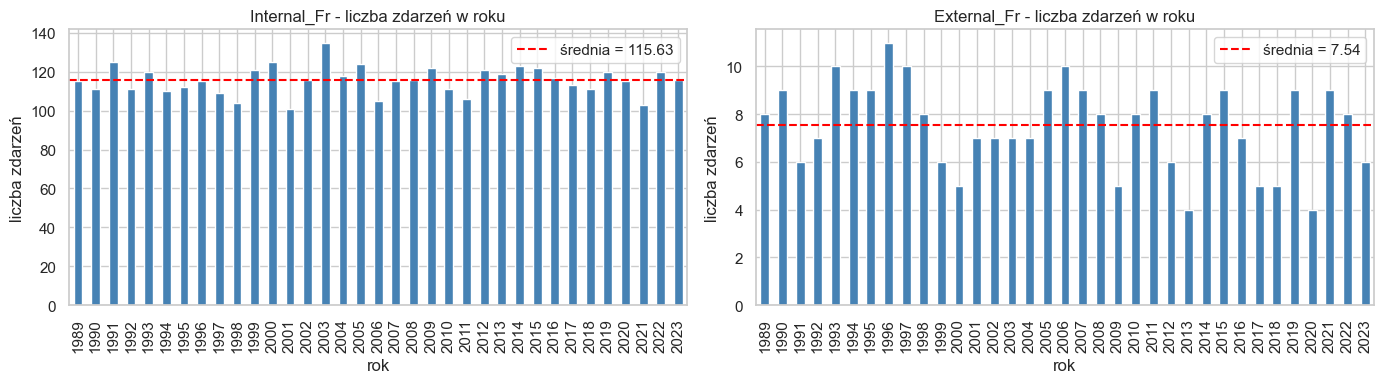

In [37]:
# Wizualizacja częstości
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, L in zip(axes, LINES):
    freq[L].plot(kind="bar", ax=ax, color="steelblue")
    ax.axhline(freq[L].mean(), color="red", linestyle="--",
               label=f"średnia = {freq[L].mean():.2f}")
    ax.set_title(f"{L} - liczba zdarzeń w roku")
    ax.set_xlabel("rok"); ax.set_ylabel("liczba zdarzeń")
    ax.legend()
plt.tight_layout(); plt.show()


Tak jak we wcześniejszej analizie zauważyłem, częstości są dość ustabilizowane, jednak widać, że znacznie mocniej w przypadku oszustw wewnętrznych. Może to być spowodowane faktem, że liczba zdarzeń zewnętrznych jest mniejsza, przez co moja próbka danych jest mniej liczna, a każda różnica o 2-3 zdarzenia jest relatywnie bardziej widoczna.

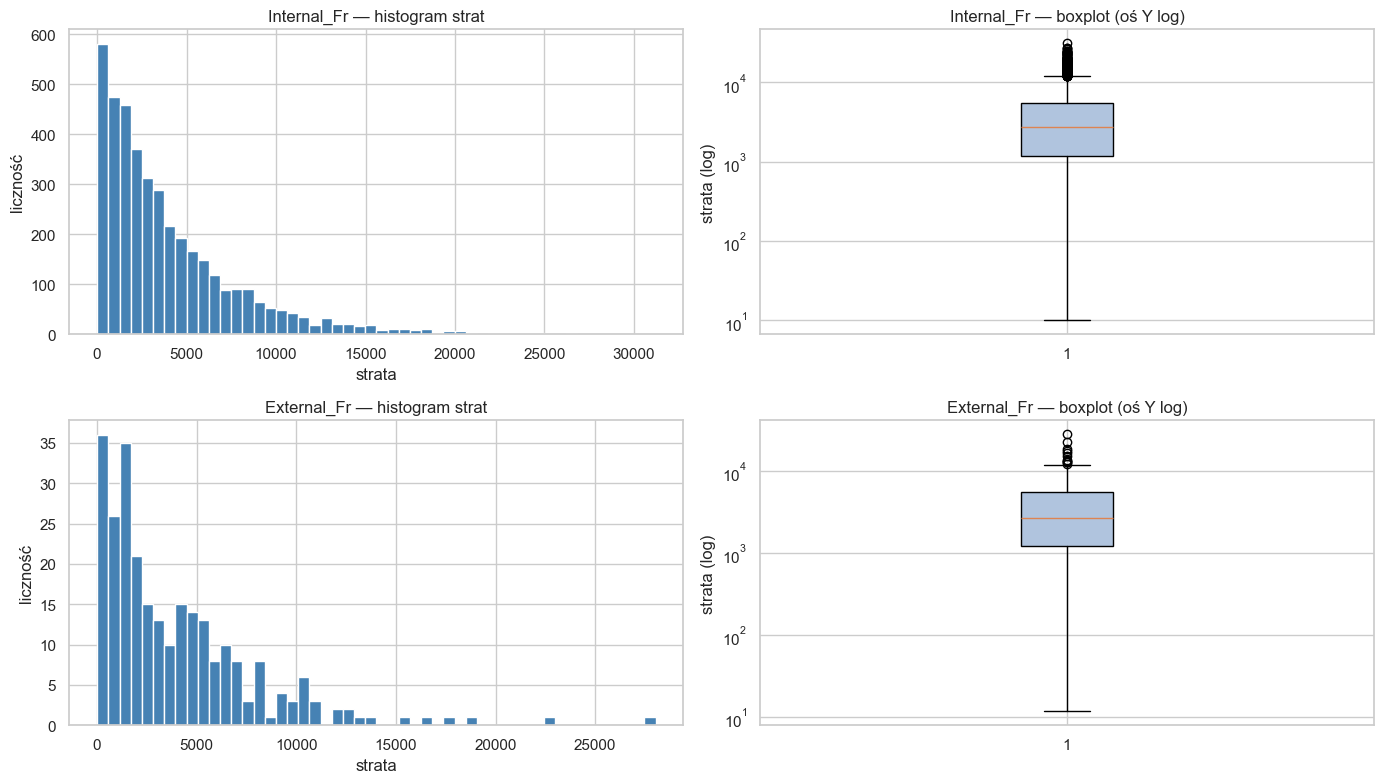

In [38]:
# Wizualizacja dotkliwości
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for row, L in enumerate(LINES):
    s = df.loc[df["linia"] == L, "strata"]
    axes[row, 0].hist(s, bins=50, color="steelblue", edgecolor="white")
    axes[row, 0].set_title(f"{L} — histogram strat")
    axes[row, 0].set_xlabel("strata"); axes[row, 0].set_ylabel("liczność")

    axes[row, 1].boxplot(s, vert=True, patch_artist=True,
                         boxprops=dict(facecolor="lightsteelblue"))
    axes[row, 1].set_yscale("log")
    axes[row, 1].set_title(f"{L} — boxplot (oś Y log)")
    axes[row, 1].set_ylabel("strata (log)")
plt.tight_layout(); plt.show()

Widzę, że w obu przypadkach występują wartości odstające i jest ich dość sporo. Potwierdza to moje wcześniejsze przypuszczenie o „grubych ogonach” w rozkładach. Jak można zauważyć, najwięcej jest najmniejszych strat, a im wyższa kwota, tym rzadziej występuje.

## Dopasowanie rozkładów i wyznaczenie parametrów

W celu dobrania optymalnych rozkładów oraz wyznaczenia ich parametrów posłużyłem się metodologią zaprezentowaną na wykładach i jego końcowych slajdach. Proces ten podzieliłem na dwa odrębne etapy obejmujące analizę częstości występowania zdarzeń oraz analizę samej dotkliwości strat. Dla rozkładu liczby zdarzeń operacyjnych, bazując na wcześniejszych wnioskach z EDA, zastosowałem klasyczną metodę momentów w celu wyestymowania parametrów rozkładu dwumianowego. Z kolei do zamodelowania wielkości pojedynczych strat wykorzystałem test zgodności Kołmogorowa-Smirnowa. Skonfrontowałem ze sobą trzy rozkłady teoretyczne:

- logarytmiczno-normalny
- wykładniczy
- Weibulla

Na podstawie wartości statystyki testowej oraz p-value wybrałem ten rozkład, który wykaże najlepsze dopasowanie do danych. Zgodnie z wytycznymi do projektu, w przypadku ewentualnego braku możliwości jednoznacznego rozstrzygnięcia, wariantem domyślnym pozostanie rozkład logarytmiczno-normalny.

In [39]:
frequency_dists = {}
severity_dists = {}

for line in LINES:
    print(f"Linia biznesowa: {line}")
    
    # Rozkład częstości (Dwumianowy z metody momentów)
    freq_data = freq[line]
    mean_freq = freq_data.mean()
    var_freq = freq_data.var()
    
    p_est = 1 - (var_freq / mean_freq)
    n_est = int(round(mean_freq / p_est))
    
    frequency_dists[line] = {'n': n_est, 'p': p_est}
    print(f"Częstość: n = {n_est}, p = {p_est:.4f}")
    
    # Rozkład dotkliwości strat
    sev_data = df.loc[df["linia"] == line, "strata"].values
    
    distributions_to_test = {
        'lognorm': stats.lognorm,
        'expon': stats.expon,
        'weibull_min': stats.weibull_min
    }
    
    best_distribution = 'lognorm'
    best_ks_statistic = float('inf')
    best_params = None
    
    print("Test Kołmogorowa-Smirnowa dla dotkliwości:")
    for dist_name, dist_obj in distributions_to_test.items():
        params = dist_obj.fit(sev_data)
        ks_statistic, p_value = stats.kstest(sev_data, dist_name, args=params)
        print(f" {dist_name}: Kołmogorow-Smirnow = {ks_statistic:.4f}, p-value = {p_value:.4f}")
        
        if ks_statistic < best_ks_statistic:
            best_ks_statistic = ks_statistic
            best_distribution = dist_name
            best_params = params
            
    severity_dists[line] = {
        'distribution': best_distribution,
        'params': best_params
    }
    
    print(f"Wybrany rozkład: {best_distribution}")
    print(f"Parametry: {best_params}\n")

Linia biznesowa: Internal_Fr
Częstość: n = 212, p = 0.5452
Test Kołmogorowa-Smirnowa dla dotkliwości:
 lognorm: Kołmogorow-Smirnow = 0.0346, p-value = 0.0001
 expon: Kołmogorow-Smirnow = 0.0088, p-value = 0.9085
 weibull_min: Kołmogorow-Smirnow = 0.0125, p-value = 0.5481
Wybrany rozkład: expon
Parametry: (10.0, 3990.011368915246)

Linia biznesowa: External_Fr
Częstość: n = 13, p = 0.5606
Test Kołmogorowa-Smirnowa dla dotkliwości:
 lognorm: Kołmogorow-Smirnow = 0.0760, p-value = 0.0898
 expon: Kołmogorow-Smirnow = 0.0440, p-value = 0.6707
 weibull_min: Kołmogorow-Smirnow = 0.0488, p-value = 0.5391
Wybrany rozkład: expon
Parametry: (11.67, 3988.3300757575757)



## Analiza testów

Powyższy skrypt wygenerował wyniki, które pozwalają na analizę dopasowanych rozkładów. W pierwszej kolejności skupiłem się na wyborze i parametryzacji rozkładu dla częstości zdarzeń. Zgodnie z metodologią przedstawioną na wykładach, o doborze odpowiedniego modelu decyduje relacja między średnią a wariancją z próby. Ponieważ we wcześniejszej fazie EDA wyliczyłem, że dla obu linii biznesowych wariancja częstości strat jest wyraźnie mniejsza od jej średniej wartości (D^2(X) < E(X)), wskazuje to na zastosowania rozkładu dwumianowego dla tych danych. Dla linii oszustw wewnętrznych parametr **n wynosi 212**, a prawdopodobieństwo **p jest na poziomie 0.5452**. W przypadku oszustw zewnętrznych parametr **n wynosi 13**, natomiast **p osiąga 0.5606**. Wartość n określa teoretyczną górną granicę liczby zdarzeń w roku i zgodnie z wcześniejszymi obserwacjami jest ona znacznie wyższa dla oszustw wewnętrznych. Ciekawy jest jednak fakt, że **prawdopodobieństwo pojedynczego sukcesu p w obu przypadkach jest niemal identyczne** i oscyluje wokół 0.55. W rzeczywistości rynkowej te dwie linie biznesowe charakteryzują się zazwyczaj zupełnie inną dynamiką, co utwierdza w przekonaniu iż dane zostały wygenerowane.

Przechodząc do wyników testu Kołmogorowa-Smirnowa dla dotkliwości strat, statystyka tego testu mierzy maksymalną odległość między dystrybuantą empiryczną a teoretyczną. Zatem im jest ona niższa, tym lepsze dopasowanie. Wartość p-value określa natomiast prawdopodobieństwo uzyskania takich danych przy założeniu, że faktycznie pochodzą one z testowanego rozkładu. Szukam więc modelu o najniższej statystyce i najwyższym p-value.

Dla oszustw wewnętrznych rozkład logarytmiczno-normalny uzyskuje **p-value na poziomie zaledwie 0.0001**, co całkowicie odrzuca ten rozkład. Rozkład Weibulla wypada znacznie lepiej, osiągając **p-value równe 0.5481**, jednak najlepszym dopasowaniem charakteryzuje się rozkład wykładniczy ze **statystyką testową 0.0088** i bardzo **wysokim p-value wynoszącym 0.9085**. Sytuacja jest analogiczna dla oszustw zewnętrznych. W tym przypadku rozkład logarytmiczno-normalny osiąga **p-value równe 0.0898**, co wprawdzie mieści się w standardowych granicach akceptacji, ale stanowi najsłabszy wynik. Rozkład **Weibulla notuje 0.5391**, a **najlepszym dopasowaniem ponownie wykazuje się rozkład wykładniczy** z **p-value na poziomie 0.6707 oraz statystyką równą 0.0440**.

Jeśli chodzi o wyliczone surowe parametry wybranego rozkładu wykładniczego. Pierwsza wartość określa przesunięcie, czyli minimalną możliwą stratę, a druga to parametr skali, stanowiący w tym przypadku wartość oczekiwaną (średnią kwotę straty). Dla **oszustw wewnętrznych minimalna strata wynosi 10.00**, a **średnia około 3990.01**. W przypadku **oszustw zewnętrznych minimum to 11.67**, a *średnia strata wynosi około 3988.33*.

## Symulacja Monte Carlo

W kolejnym kroku przystąpiłem do kluczowej części metody LDA, to znaczy do symulacji rozkładu strat za pomocą metody Monte Carlo. Proces ten opiera się na wygenerowaniu 10 000 niezależnych scenariuszy. Zgodnie z podstawowymi założeniami uproszczonego modelu, przyjąłem całkowity brak korelacji pomiędzy częstością zdarzeń w poszczególnych liniach biznesowych, gdyż w poleceniu nie było mowa o istenijącej korelacji.

W odróżnieniu od ryzyka kredytowego z poprzdniego projektu, gdzie analizowałem spadek wartości portfela, w ryzyku operacyjnym modelowana jest bezpośrednio wartość straty. Z tego względu miara 99,9% **OpVaR (Operational Value at Risk)** jest wyznaczana jako kwantyl rzędu 99,9% z wektora zsumowanych strat rocznych. Oznacza to kwotę, która nie zostanie przekroczona z prawdopodobieństwem 99,9%. **OpES (Operational Expected Shortfall)** to z kolei wartość oczekiwana w skrajnym ogonie, czyli średnia wielkość strat dla tych scenariuszy, które przekroczyły poziom OpVaR. Uzyskane wyniki oraz symulacyjny rozkład całkowitej straty operacyjnej zaprezentowałem w dalszej części na wykresie.

In [40]:
np.random.seed(42)

# Ilość symulacji
N = 10_000

# Tablica na zsumowane straty z obu linii dla każdego z N scenariuszy
total_losses = np.zeros(N)

for line in LINES:
    # Pobieram zapisane parametry z Kroku 2 (n i p dla rozkładu dwumianowego)
    n_est = frequency_dists[line]['n']
    p_est = frequency_dists[line]['p']
    
    dist_name = severity_dists[line]['distribution']
    sev_params = severity_dists[line]['params']
    dist_obj = getattr(stats, dist_name)
    
    # Losujem częstotliwość (ile zdarzeń wystąpiło) dla każdego z N scenariuszy używając rozkładu dwumianowego
    freqs = np.random.binomial(n=n_est, p=p_est, size=N)
    
    # Losuję dotkliwość używając dobranych rozkładów wykładniczych (zgodnie z wcześniejszymi ustaleniami)
    total_events = freqs.sum() # Łączna liczba zdarzeń we wszystkich scenariuszach (N iteracji * ilość)
    sev_draws = dist_obj.rvs(*sev_params, size=total_events)
    
    # Agreguję straty do odpowiednich scenariuszy
    # np.repeat tworzy indeksy scenariuszy
    # np. Weź numer 0 i powtórz go 2 razy. Weź numer 1 i powtórz go 0 razy po to by nie robić typowej pętli, tylko zrobić jak najwięcej wektorowo
    scenario_idx = np.repeat(np.arange(N), freqs)
    # np.bincount sumuje straty dla danego indeksu
    # weights=sev_draws - Zamiast zwykłego zliczania ile razy wystąpił dany scenariusz (co dałoby tylko liczbę zdarzeń), ten parametr każe funkcji sumować konkretne kwoty strat przypisane do danego scenariusza.
    line_losses = np.bincount(scenario_idx, weights=sev_draws)
    
    # Dodaje straty z danej linii biznesowej do całkowitych strat banku
    total_losses += line_losses

# Obliczam metryki ryzyka
EL = total_losses.mean() # Oczekiwana Strata

# OpVaR 99.9% - kwantyl z prawego ogona (straty, więc szukamy najwyższych wartości)
OpVaR_999 = np.quantile(total_losses, 0.999)

# OpES 99.9% - średnia ze strat, które przekroczyły VaR
OpES_999 = total_losses[total_losses > OpVaR_999].mean()

print(f"Oczekiwana strata roczna (EL): {EL:>15,.2f} zł")
print(f"OpVaR (99.9%):                 {OpVaR_999:>15,.2f} zł")
print(f"OpES  (99.9%):                 {OpES_999:>15,.2f} zł")

Oczekiwana strata roczna (EL):      491,186.11 zł
OpVaR (99.9%):                      663,087.97 zł
OpES  (99.9%):                      680,800.43 zł


In [41]:
fig = go.Figure()

fig.add_trace(go.Histogram(
    x=total_losses, nbinsx=100, marker_color='#3498db', opacity=0.7, name='Rozkład sumy strat'
))

fig.add_vline(x=EL, line_color='green', line_width=2, line_dash='solid')
fig.add_vline(x=OpVaR_999, line_color='red', line_width=2, line_dash='dash')
fig.add_vline(x=OpES_999, line_color='orange', line_width=2, line_dash='dash')

fig.add_trace(go.Scatter(x=[None], y=[None], mode='lines', 
                         line=dict(color='green', width=2, dash='solid'), 
                         name=f'Oczekiwana Strata (EL) = {EL:,.0f} zł'))
fig.add_trace(go.Scatter(x=[None], y=[None], mode='lines', 
                         line=dict(color='red', width=2, dash='dash'), 
                         name=f'OpVaR (99.9%) = {OpVaR_999:,.0f} zł'))
fig.add_trace(go.Scatter(x=[None], y=[None], mode='lines', 
                         line=dict(color='orange', width=2, dash='dash'), 
                         name=f'OpES (99.9%) = {OpES_999:,.0f} zł'))

fig.update_layout(
    title=f'Rozkład strat operacyjnych ({N:,} scenariuszy Monte Carlo)',
    xaxis_title='Całkowita strata w roku [zł]',
    yaxis_title='Liczba scenariuszy',
    barmode='overlay',
    legend=dict(
        orientation="v",
        yanchor="top",
        y=1,
        xanchor="left",
        x=1.05,
        bordercolor="Black",
        borderwidth=1
    )
)

fig.show()

## Monte Carlo - analiza wyników

Po przeprowadzeniu symulacji Monte Carlo, zsumowałem wygenerowane straty dla obu linii biznesowych w każdym ze scenariuszy, uzyskując w ten sposób pełny rozkład rocznych strat operacyjnych banku. Na jego podstawie wyznaczyłem kluczowe miary ryzyka.

Oczekiwana strata roczna, czyli **Expected Loss, wyniosła 491 186,11 zł.** Jest to średnia wartość, jakiej firma może się spodziewać w standardowym roku operacyjnym z tytułu połączonych oszustw wewnętrznych i zewnętrznych

Następnie wyznaczyłem miarę **99,9% OpVaR, która wynosi 663 087,97 zł.** Wartość ta oznacza, że z prawdopodobieństwem 99,9% całkowite straty operacyjne firmy w nadchodzącym roku nie przekroczą tej granicy.

Na koniec analizy obliczyłem również **99,9% OpES, czyli Expected Shortfall, która wyniosła 680 800,43 zł.** Wskaźnik ten informuje, jaka będzie średnia wielkość całkowitej straty w tych skrajnych 0,1% przypadków, w których wyznaczony próg OpVaR zostanie jednak przekroczony.

Różnica między OpVaR a OpES wynosi ok. 18 tys. zł. Oznacza to, że jeśli moja strata przekroczy próg VaR, to średnio będzie ona o około 18 tys. wyższa niż VaR, osiągając wspomniany poziom 680 800,43 zł.